<h1 style="color: #0D47A1; font-weight: bold">
    Entrega TP3
</h1>

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import numpy as np
import random
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch import nn

In [4]:
sys.path.append("..")

from src.utils.plotting import (plot_random_images, plot_training_history,
    evaluate_model, compare_models)
from src.utils.preprocessing import (data_split, scaler)
from src.evaluation.grid_search import random_grid_search_custom, random_grid_search_torch
from src.training.train import train_and_eval

from src.models.custom.layers import DenseLayer
from src.models.custom.neural_network import SecuentialNeuralNetwork
from src.models.custom.activations import ReLU, SoftMax
from src.models.custom.optimizers import GradientDescent, ADAM
from src.models.custom.loss import CrossEntropy
from src.models.torch.mlp import MLP

<h2 style="color: #1976D2; font-weight: 500">
    1. Análisis exploratorio y preprocesamiento
</h2>

In [5]:
X_images = np.load("../data/X_images.npy")
y_images = np.load("../data/y_images.npy")

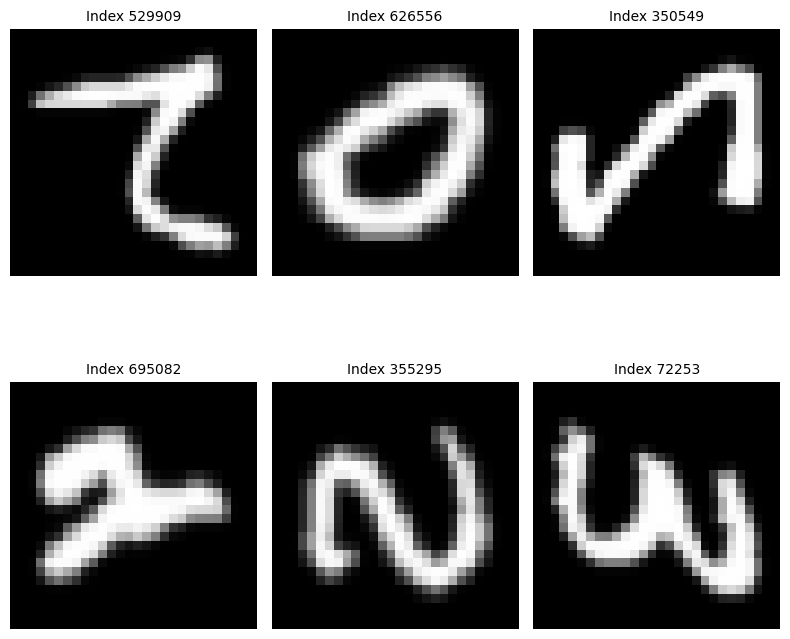

In [6]:
plot_random_images(X_images, image_shape=(28, 28), n=6)

In [7]:
X_images = X_images.reshape(X_images.shape[0], -1)

Cantidad de clases

In [8]:
output_dim = len(set(y_images.tolist()))
print("Cantidad de clases:", output_dim)

Cantidad de clases: 47


In [9]:
input_dim = X_images.shape[1]
print("Cantidad de 'features':", input_dim)

Cantidad de 'features': 784


In [10]:
rows = X_images.shape[0]
print(rows)

809555


Normalizo el dataset dividiendo por 255 así el máximo es 1.

Luego:

Dividir en Train, Validation y Test
- Dev 0.9, Test 0.1
- Train 7/9 de Dev, Val 2/9 de Dev

Sobre el dataset total:
- Train 0.7, Val 0.2, Test 0.1

In [ ]:
X_images = scaler(X_images)

# Shuffle and split
X_dev, y_dev, X_test, y_test = data_split(X_images, y_images, frac=0.8)
X_train, y_train, X_val, y_val = data_split(X_dev, y_dev, frac=7/9)

In [46]:
total_epochs = 50

<h2 style="color: #1976D2; font-weight: 500">
    2. Implementación y Entrenamiento de una Red Neuronal Básica
</h2>

Incisos **a** y **b** en `src/models/`

**Modelo M0**

- 1ra capa oculta:
    - 128 nodos con activación ReLU
- 2da capa oculta:
    - 64 nodos con activación ReLU
- Capa de salida:
    - 1 nodo con activación SoftMax

In [12]:
layers_m0 = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m0 = SecuentialNeuralNetwork(
    layers_m0, 
    GradientDescent(learning_rate=0.05), 
    CrossEntropy()
)

Entrenamiento del modelo

In [ ]:
m0.fit(X=X_train, y=y_train, epochs=total_epochs, batch_size=None, X_val=X_val, y_val=y_val, early_stopping=None)

Training: 100%|██████████| 50/50 [15:41<00:00, 18.82s/ep] 


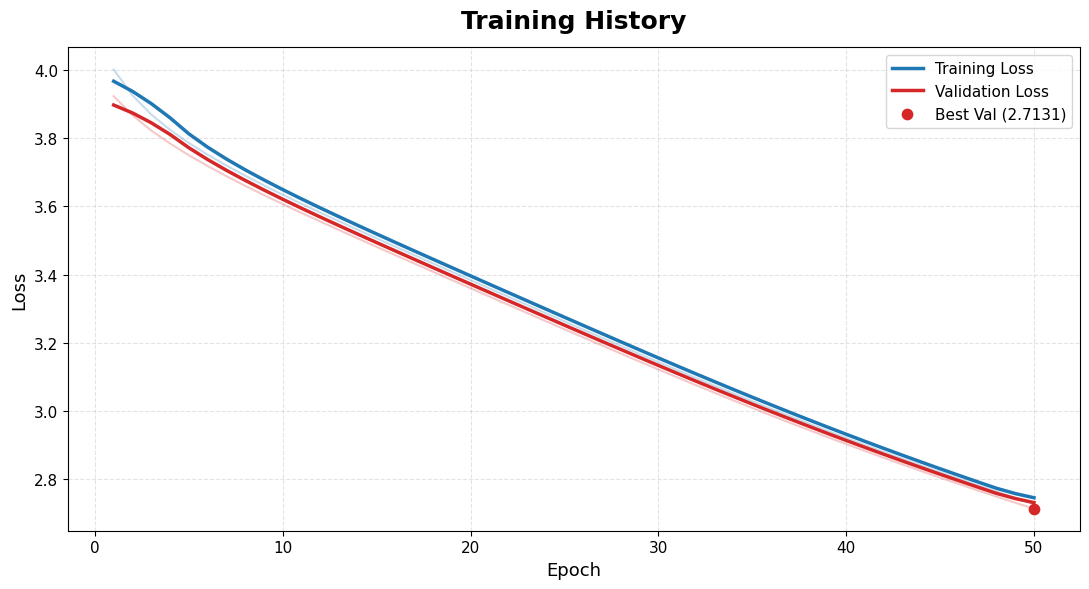

In [14]:
plot_training_history(m0.train_loss, m0.val_loss)

Métricas

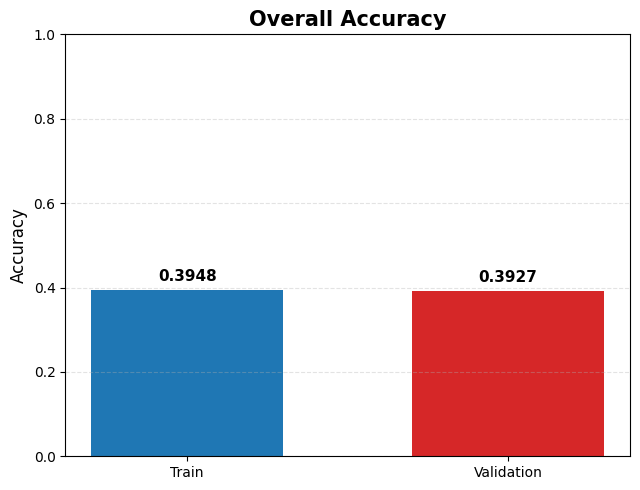

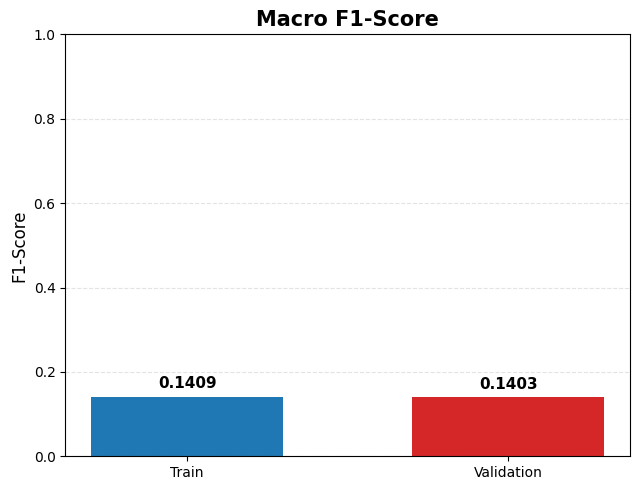

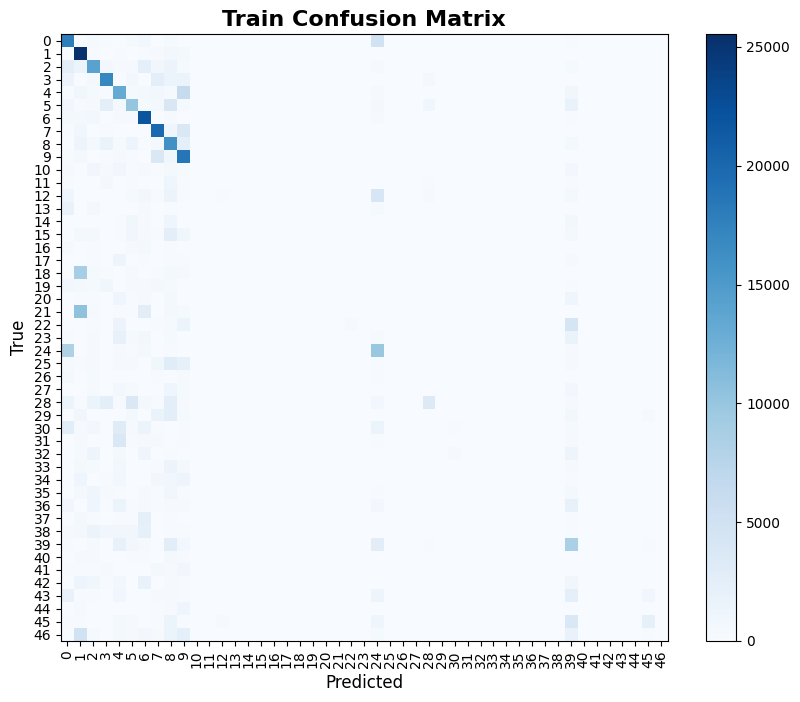

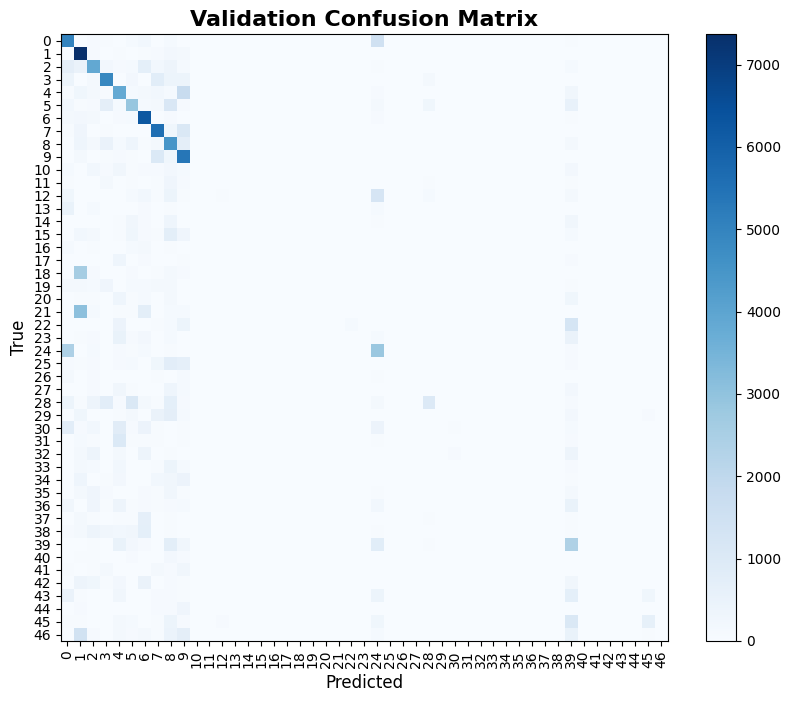

In [15]:
evaluate_model(m0, X_train, y_train, X_val, y_val)

<h2 style="color: #1976D2; font-weight: 500">
    3. Implementación y Entrenamiento de una Red Neuronal Avanzada
</h2>

**Mejoras al algoritmo de entrenamiento y reportar el efecto observado sobre el tiempo de entrenamiento y la performance del modelo resultante**

In [ ]:
epochs_test = 50

search_train_size = min(X_train.shape[0]*0.3, X_train.shape[0])
search_val_size = min(X_val.shape[0]*0.3, X_val.shape[0])

search_train_idx = np.random.choice(X_train.shape[0], size=search_train_size, replace=False)
search_val_idx = np.random.choice(X_val.shape[0], size=search_val_size, replace=False)

X_train_search = X_train[search_train_idx]
y_train_search = y_train[search_train_idx]
X_val_search = X_val[search_val_idx]
y_val_search = y_val[search_val_idx]

- **Rate scheduling lineal (con saturación)**

In [17]:
linear_scheduling = {"type": "linear", "lr_min": 0.001, "k": 0.01}

layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01, scheduling=linear_scheduling), 
    CrossEntropy()
)

In [18]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 30/30 [00:17<00:00,  1.70ep/s]


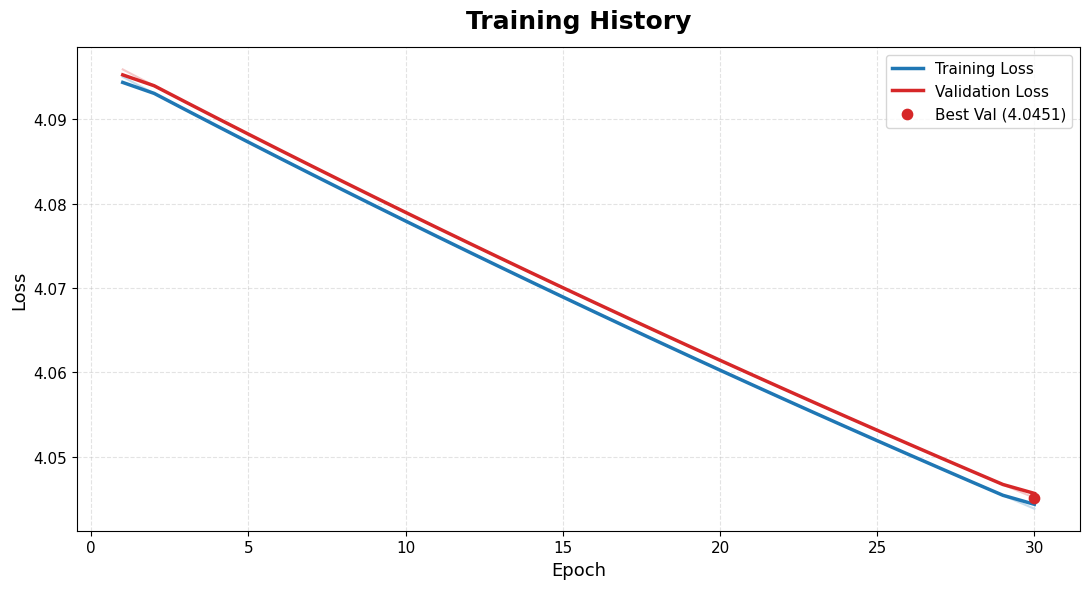

In [19]:
plot_training_history(m_test.train_loss, m_test.val_loss)

- **Rate scheduling exponencial**

In [20]:
exponential_scheduling = {"type": "exponential", "gamma": 0.9}

layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01, scheduling=exponential_scheduling), 
    CrossEntropy()
)

In [21]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 30/30 [00:15<00:00,  1.98ep/s]


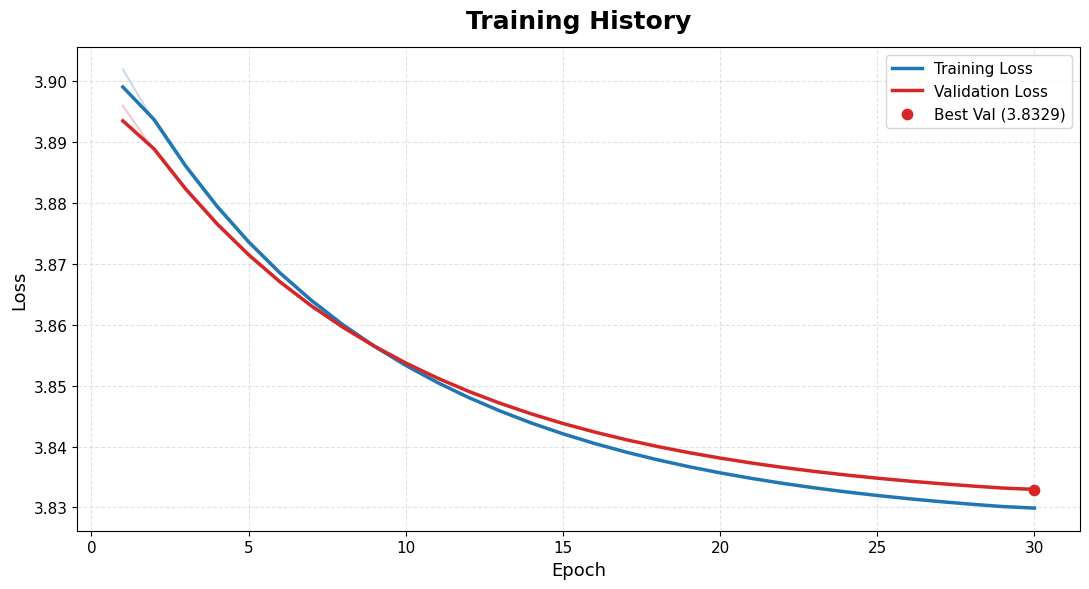

In [22]:
plot_training_history(m_test.train_loss, m_test.val_loss)

- **Mini-batch stochastic gradient descent**

In [39]:
layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy()
)

In [ ]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=128, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 30/30 [00:29<00:00,  1.00ep/s]


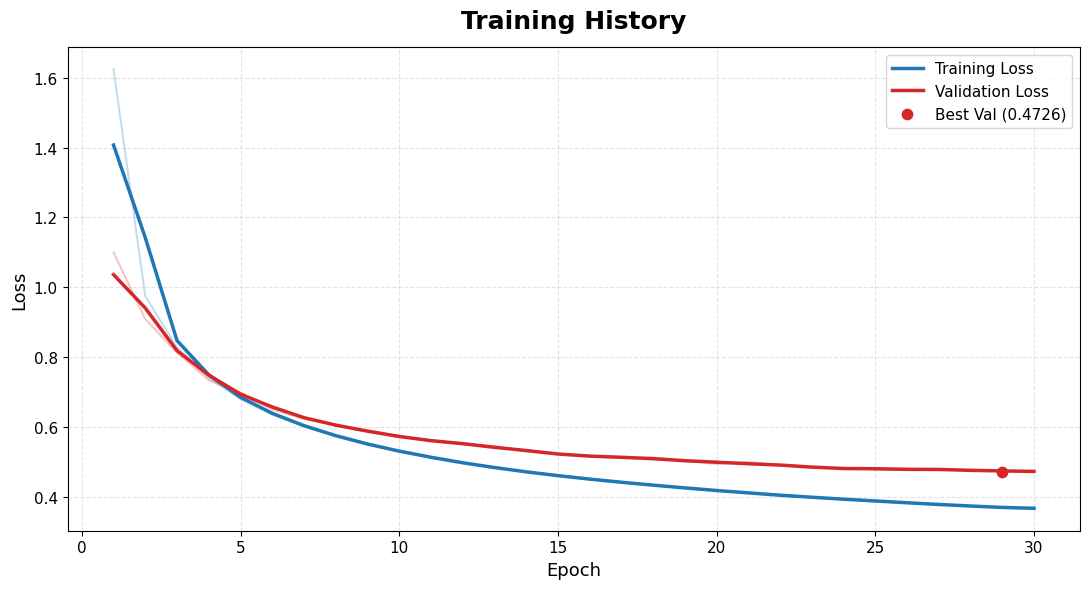

In [41]:
plot_training_history(m_test.train_loss, m_test.val_loss)

- **Optimizador Adam**

In [26]:
layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    ADAM(), 
    CrossEntropy()
)

In [27]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 30/30 [00:15<00:00,  1.90ep/s]


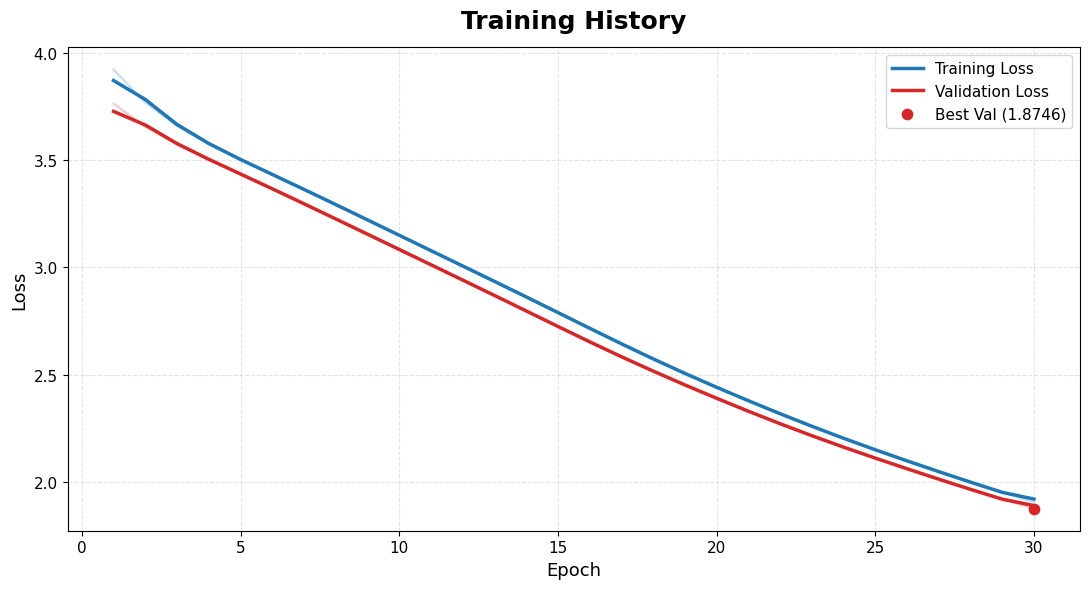

In [28]:
plot_training_history(m_test.train_loss, m_test.val_loss)

- **Regularización (L2, Early Stopping)**

In [29]:
l2_test = 0.01

layers_m_test = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=l2_test),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=l2_test),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=l2_test)
]

m_test = SecuentialNeuralNetwork(
    layers_m_test, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy()
)

In [30]:
m_test.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=10)

Training: 100%|██████████| 30/30 [00:16<00:00,  1.77ep/s]


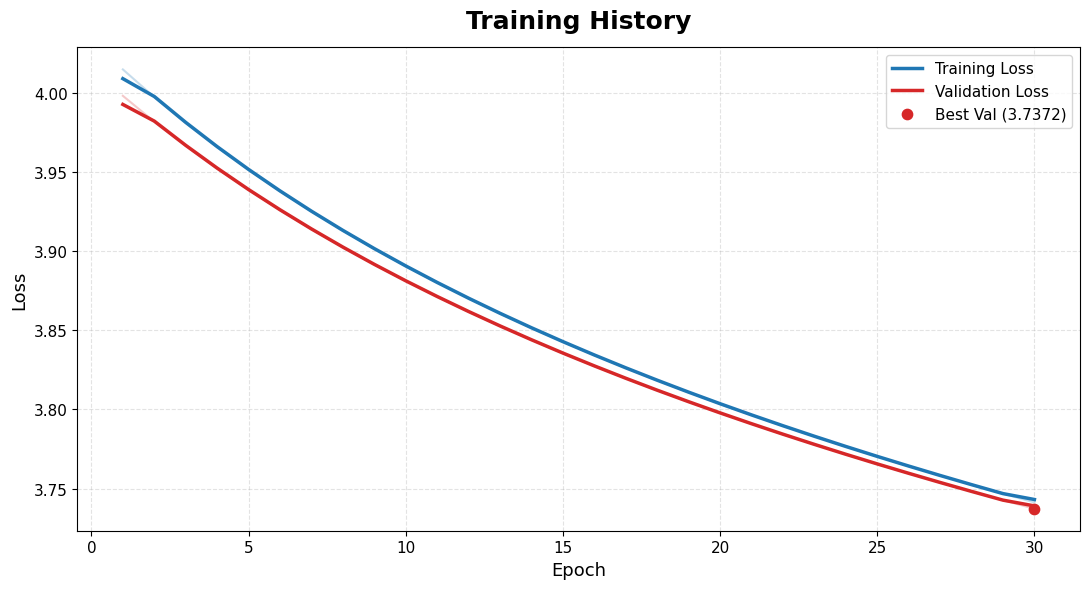

In [31]:
plot_training_history(m_test.train_loss, m_test.val_loss)

---

**Random Grid Search para M1**

In [ ]:
possible_configs = {
    "layers": [
        (128, 64), 
        (256, 128, 64), 
        (256, 128), 
        (256, 128, 64)],
    "l2": [0., 1e-5, 1e-3],
    "batch_size": [128, 256],
    "scheduling": [
        None, 
        {"type": "linear", "lr_min": 1e-5, "k": 1e-5}, 
        {"type": "exponential", "gamma": 0.99}]
}

early_stopping = 8
K_models = 7

models, model_config = random_grid_search_custom(input_dim, output_dim, X_train_search, 
    y_train_search, X_val_search, y_val_search, epochs_test, K_models, 
    possible_configs, early_stopping=early_stopping)

  0%|          | 0/7 [00:00<?, ?it/s]


Model: 0
Config: {'layers': (128, 64), 'l2': 0.0, 'batch_size': 256, 'scheduling': None}



 14%|█▍        | 1/7 [00:19<01:58, 19.80s/it]

Early stopping after epoch: 22


Model: 1
Config: {'layers': (256, 128, 64), 'l2': 0.0, 'batch_size': 128, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



 29%|██▊       | 2/7 [01:15<03:23, 40.78s/it]

...

Early stopping after epoch: 11


Model: 5
Config: {'layers': (256, 128, 64), 'l2': 0.0, 'batch_size': 256, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



 86%|████████▌ | 6/7 [03:27<00:33, 33.16s/it]

Early stopping after epoch: 15


Model: 6
Config: {'layers': (256, 128), 'l2': 0.0, 'batch_size': 128, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



100%|██████████| 7/7 [04:22<00:00, 37.49s/it]

Early stopping after epoch: 11



In [43]:
compare_models(models, list(model_config.keys()))

 Model  Best Val Loss  Best Train Loss  Best Epoch  Final Train Loss  Final Val Loss  Epochs Trained
     2       0.440003         0.402761          28          0.400953        0.447259              30
     3       0.471587         0.354932           9          0.276887        0.552943              19
     0       0.477186         0.344077          13          0.277789        0.510795              23
     5       1.024133         0.999909           6          0.999909        1.024133              16
     6       1.105593         1.081157           2          1.081134        1.105593              12
     1       1.145451         1.121913           2          1.121884        1.145451              12
     4       1.443962         1.427745           2          1.427726        1.443962              12


Cargo el mejor modelo encontrado, lo entreno y evalúo con todo el Train

In [47]:
best_index = 0
best_val = np.inf
for i in range(len(models)):
    best_model_val = min(models[i].val_loss)
    if best_model_val < best_val:
        best_val = best_model_val
        best_index = i

config_m1 = model_config[best_index]

layers_m1 = []
last_dim = input_dim
for next_dim in config_m1["layers"]:
    layers_m1.append(
        DenseLayer(
            input_dim=last_dim, 
            output_dim=next_dim, 
            activation=ReLU(), 
            l2_regularization=config_m1["l2"]
    ))
    last_dim = next_dim
    
layers_m1.append(
    DenseLayer(
        input_dim=last_dim, 
        output_dim=output_dim, 
        activation=SoftMax(), 
        l2_regularization=config_m1["l2"]
))

m1 = SecuentialNeuralNetwork(layers_m1, ADAM(), CrossEntropy())


In [48]:
m1.fit(X_train, y_train, epochs=total_epochs, batch_size=config_m1["batch_size"], 
    X_val=X_val, y_val=y_val, early_stopping=early_stopping)

Training:  24%|██▍       | 12/50 [06:07<19:23, 30.62s/ep]

Early stopping after epoch: 12


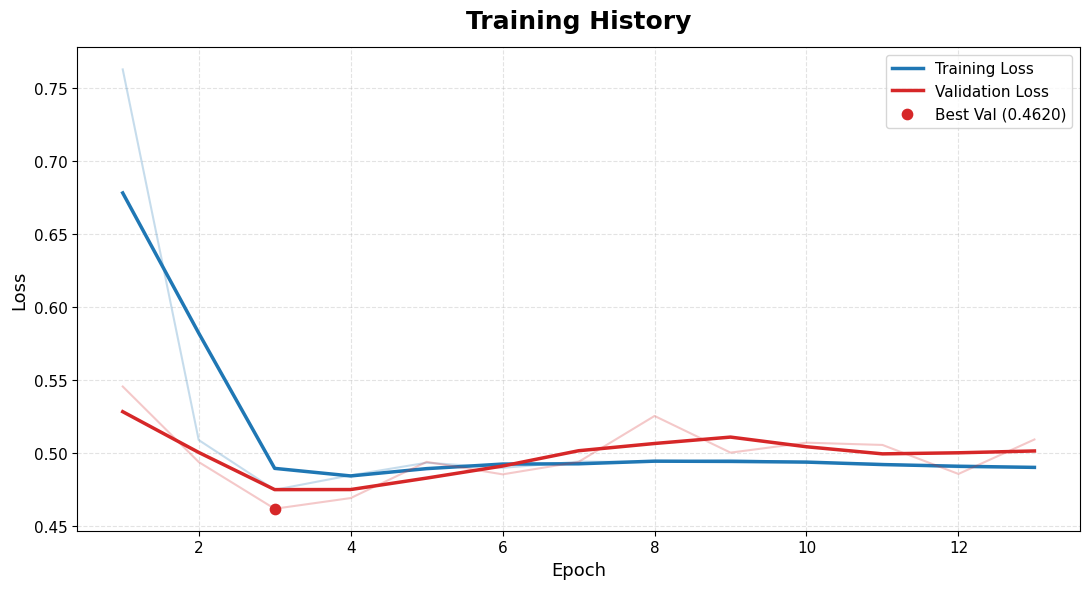

In [49]:
plot_training_history(m1.train_loss, m1.val_loss)

Métricas

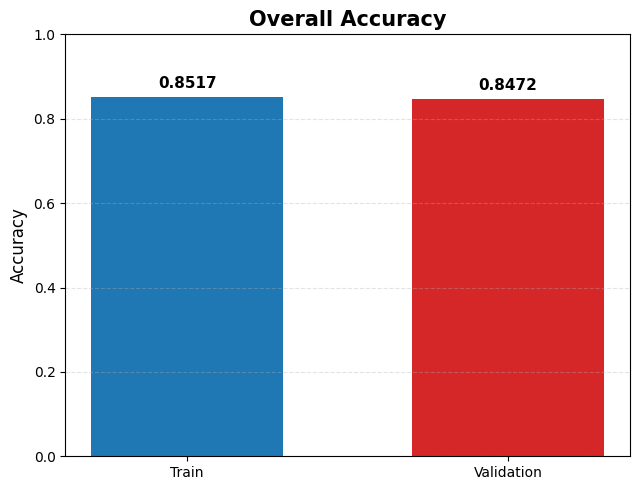

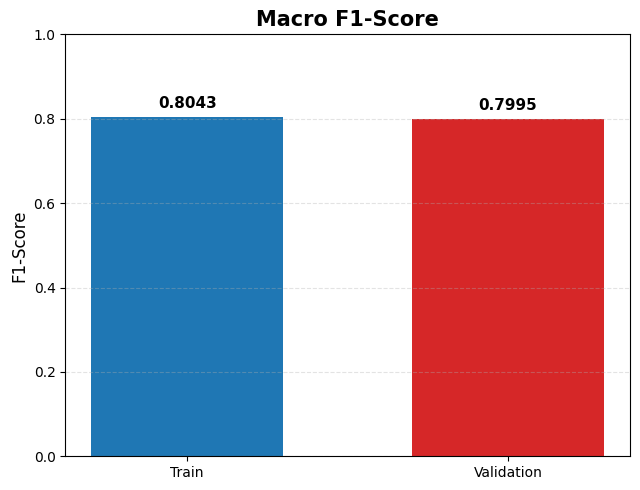

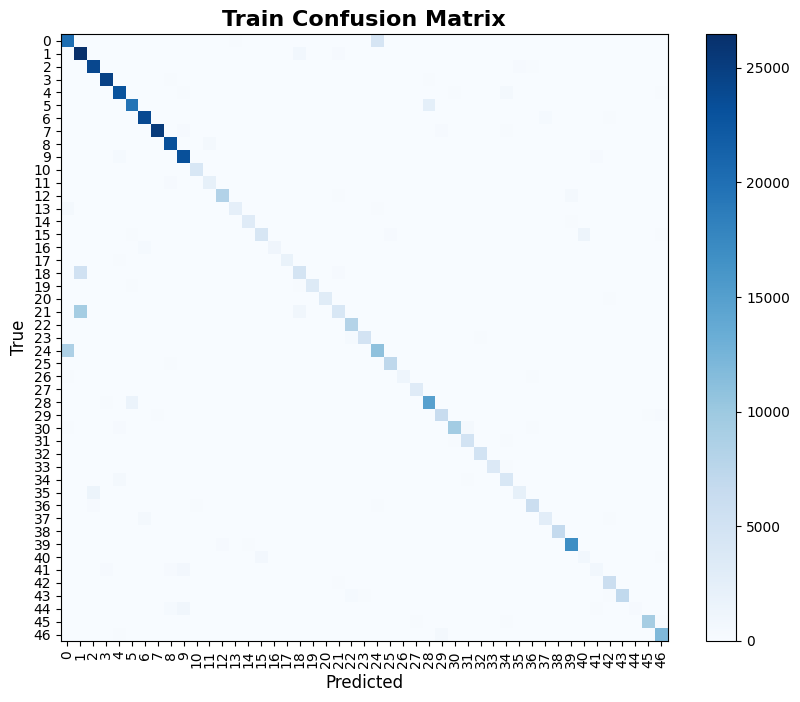

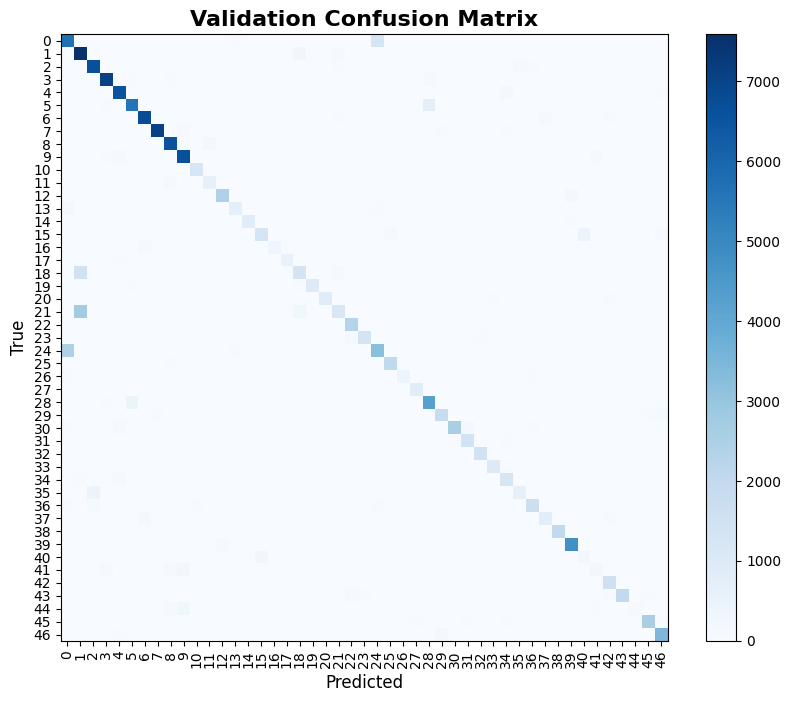

In [50]:
evaluate_model(m1, X_train, y_train, X_val, y_val)

<h2 style="color: #1976D2; font-weight: 500">
    4. Desarrollo de una Red Neuronal con PyTorch
</h2>

Device y Dataset

In [51]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long()

X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

Using mps device


**M2**

In [52]:
layers_m2 = [*config_m1["layers"]]
m2 = MLP(input_dim, layers_m2, output_dim, dropout=0., activation=nn.ReLU)
optimizer_m2 = torch.optim.Adam(m2.parameters(), weight_decay=config_m1["l2"])
loss_fn_m2 = torch.nn.CrossEntropyLoss()

train_loader_m2 = DataLoader(
    train_dataset,
    batch_size=config_m1["batch_size"],
    shuffle=True
)

val_loader_m2 = DataLoader(
    val_dataset,
    batch_size=config_m1["batch_size"],
    shuffle=False
)

Training

In [53]:
m2 = m2.to(device)

train_loss, val_loss = train_and_eval(train_loader_m2, val_loader_m2, m2, loss_fn_m2, 
    optimizer_m2, device, epochs=total_epochs, early_stopping=early_stopping, 
    scheduling=config_m1["scheduling"], lr_0=0.001)

 60%|██████    | 30/50 [04:45<03:10,  9.51s/it]

Early stopping after epoch: 30


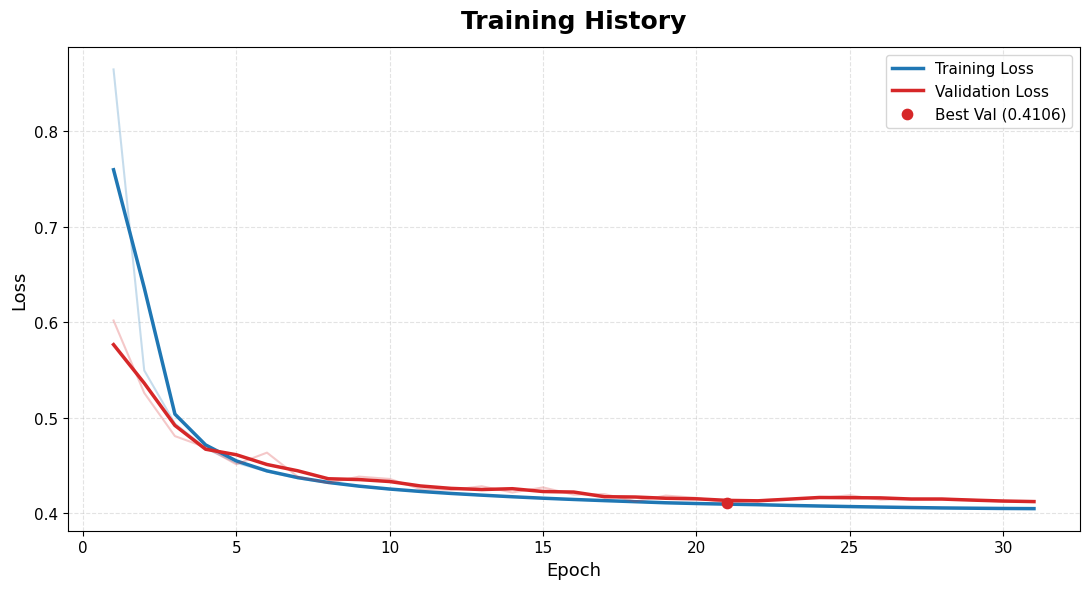

In [54]:
plot_training_history(train_loss, val_loss)

Métricas

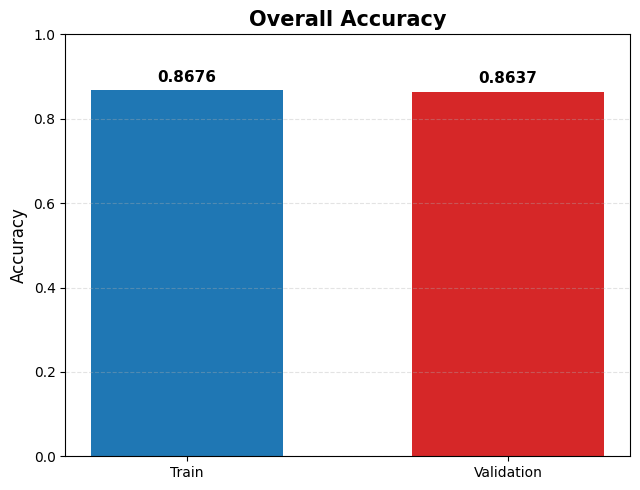

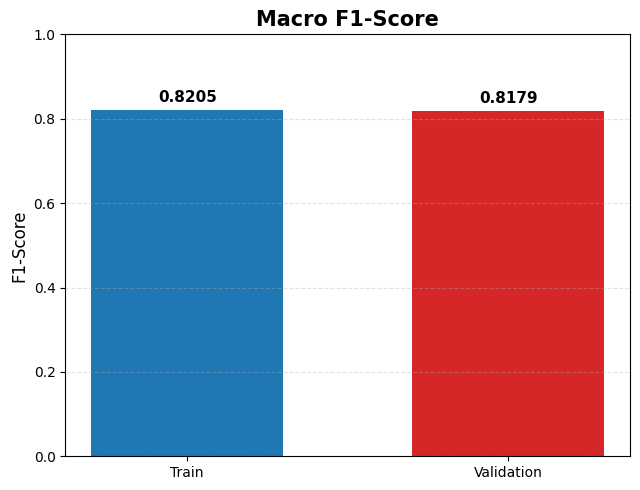

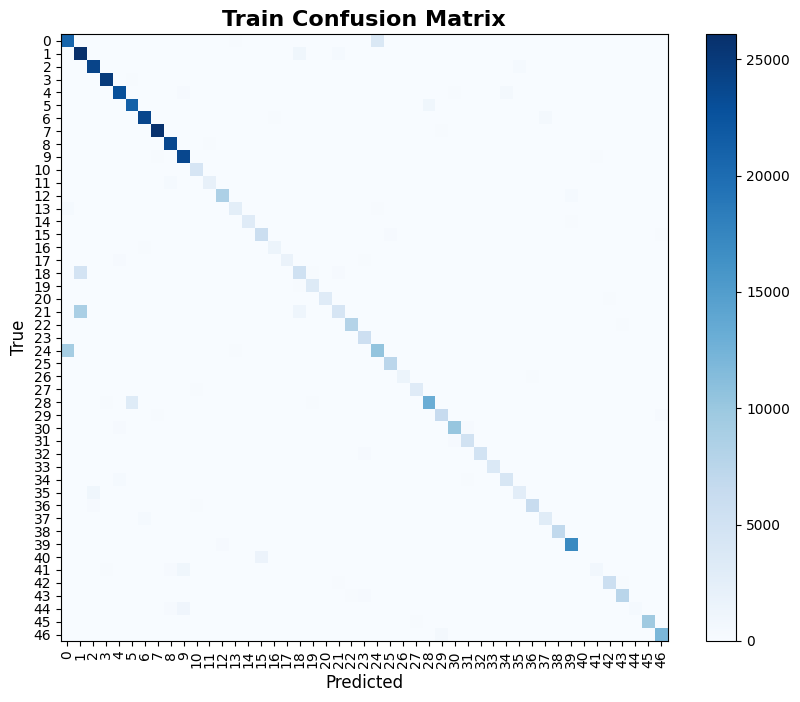

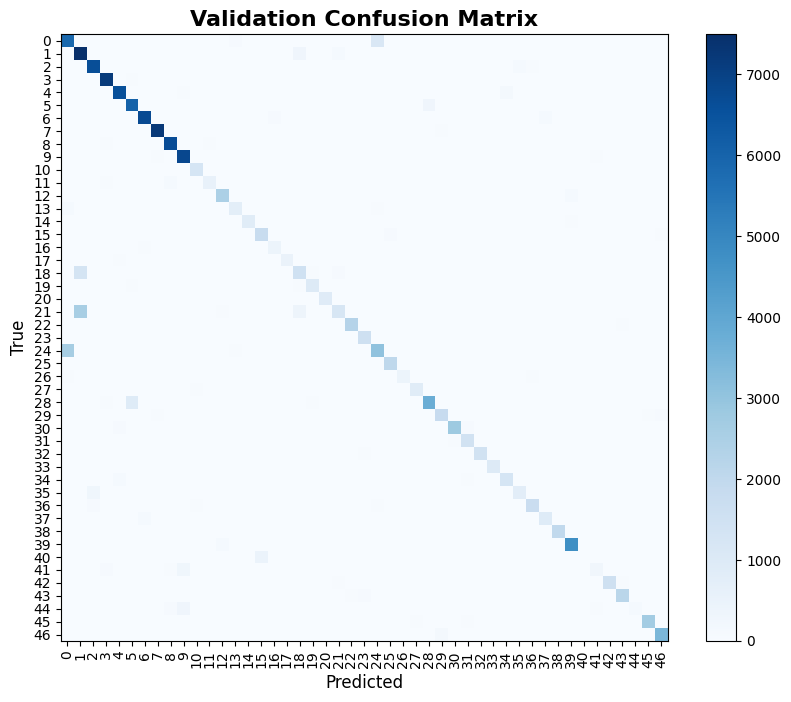

In [55]:
evaluate_model(m2, X_train, y_train, X_val, y_val)

**Random Grid Search para M3**

In [ ]:
X_train_search_tensor = torch.from_numpy(X_train_search).float()
y_train_search_tensor = torch.from_numpy(y_train_search).long()

X_val_search_tensor = torch.from_numpy(X_val_search).float()
y_val_search_tensor = torch.from_numpy(y_val_search).long()

train_search_dataset = TensorDataset(X_train_search_tensor, y_train_search_tensor)
val_search_dataset = TensorDataset(X_val_search_tensor, y_val_search_tensor)

possible_configs = {
    "layers": [
        [128, 64],
        [256, 128],
        [512, 256, 128],
    ],
    "dropout": [0.0, 0.2, 0.4],
    "lr": [1e-2, 1e-3],
    "l2": [0.0, 1e-5, 1e-3],
    "batch_size": [128, 256],
    "optimizer": [torch.optim.AdamW, torch.optim.SGD],
    "activation": [nn.ReLU, nn.LeakyReLU, nn.SiLU],
    "batch_norm": [True, False],
    "scheduling": [
        None, 
        {"type": "linear", "lr_min": 1e-5, "k": 1e-5}, 
        {"type": "exponential", "gamma": 0.99}]
}

early_stopping = 8
K_models = 5

In [63]:
models, model_config = random_grid_search_torch(input_dim, output_dim, train_search_dataset, val_search_dataset, 
    total_epochs, K_models, possible_configs, early_stopping, device)

  0%|          | 0/7 [00:00<?, ?it/s]


Model: 0
Config: {'layers': [128, 64], 'dropout': 0.0, 'lr': 0.001, 'l2': 0.0, 'batch_size': 128, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.SiLU'>, 'batch_norm': True, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



 14%|█▍        | 1/7 [02:37<15:43, 157.30s/it]



Model: 1
Config: {'layers': [784, 512, 256], 'dropout': 0.0, 'lr': 0.001, 'l2': 0.0, 'batch_size': 128, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.ReLU'>, 'batch_norm': True, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



 29%|██▊       | 2/7 [06:54<17:59, 215.96s/it]

...

 71%|███████▏  | 5/7 [13:56<05:32, 166.08s/it]



Model: 5
Config: {'layers': [784, 256, 128], 'dropout': 0.4, 'lr': 0.01, 'l2': 0.0001, 'batch_size': 128, 'optimizer': <class 'torch.optim.sgd.SGD'>, 'activation': <class 'torch.nn.modules.activation.SiLU'>, 'batch_norm': False, 'scheduling': {'type': 'exponential', 'gamma': 0.99}}



 86%|████████▌ | 6/7 [17:15<02:57, 177.27s/it]



Model: 6
Config: {'layers': [256, 128], 'dropout': 0.4, 'lr': 0.01, 'l2': 0.0, 'batch_size': 512, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'activation': <class 'torch.nn.modules.activation.LeakyReLU'>, 'batch_norm': True, 'scheduling': None}



100%|██████████| 7/7 [18:23<00:00, 157.61s/it]

In [64]:
compare_models(models, list(model_config.keys()))

 Model  Best Val Loss  Best Train Loss  Best Epoch  Final Train Loss  Final Val Loss  Epochs Trained
     6       0.405190         0.464915          50          0.464915        0.405190              50
     4       1.363083         1.360578          50          1.360578        1.363083              50
     1       1.436196         1.430519          50          1.430519        1.436196              50
     3       2.336333         2.356308          50          2.356308        2.336333              50
     0       2.697162         2.700518          50          2.700518        2.697162              50
     2       3.848705         3.848665          50          3.848665        3.848705              50
     5       3.853959         3.854166          50          3.854166        3.853959              50
